# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_squared_error, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import shap
# Import your chosen baseline model
from sklearn.ensemble import RandomForestClassifier

/Users/sacksen/miniconda3/envs/geo_env_clean/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Choice

[Explain why you've chosen a particular model as the baseline. This could be a simple statistical model or a basic machine learning model. Justify your choice.]

A Random Forest is well suited as a baseline for this dataset because it handles high-dimensional, non-linear features effectively and requires minimal preprocessing of the biovolume bins. It is robust to noise, correlations, and class imbalance, and it provides interpretable feature importances. This makes it a strong, reliable reference model before exploring more complex approaches.

## Feature Selection

[Indicate which features from the dataset you will be using for the baseline model, and justify your selection.]

Including:
For the baseline model, all biovolume-normalized bin features (approximately 680 columns covering ESD ranges from 0.203–0.256 mm up to 8.19–10.3 mm) are used. These variables capture the full size-spectrum distribution of the plankton community and represent the core ecological signal of each profile.

Excluding:
Profile_id, because it is an identifier and provides no predictive ecological information.
cluster, because it is the target label.

This selection yields a clean baseline that leverages only meaningful biological measurements, avoids information leakage, and provides a robust point of comparison for future feature engineering.


In [4]:
# Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
df_bioVol = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')
#df_clusters = pd.read_pickle('../Data/Profile_id_to_clusters.pkl')
df_clusters = pd.read_pickle('../Data/Profile_id_to_clusters_per_variable.pkl')
#df.info()
df_clusters.info()

# Transform the dataset into one big array
df_merged = df_bioVol.merge(df_clusters[['Profile_id', 'cluster']], 
                           on='Profile_id', 
                           how='left')
#df_merged.info()
df_merged.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5619 entries, 0 to 5618
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Profile_id  5619 non-null   object
 1   cluster     5619 non-null   int32 
dtypes: int32(1), object(1)
memory usage: 66.0+ KB


,Profile_id,depth,depth_bin,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm),Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm),Biovolume norm [ppm mm-1] (ESD: 0.323-0.406 mm),Biovolume norm [ppm mm-1] (ESD: 0.406-0.512 mm),Biovolume norm [ppm mm-1] (ESD: 0.512-0.645 mm),Biovolume norm [ppm mm-1] (ESD: 0.645-0.813 mm),Biovolume norm [ppm mm-1] (ESD: 0.813-1.02 mm),...,Biovolume norm [ppm mm-1] (ESD: 1.29-1.63 mm),Biovolume norm [ppm mm-1] (ESD: 1.63-2.05 mm),Biovolume norm [ppm mm-1] (ESD: 2.05-2.58 mm),Biovolume norm [ppm mm-1] (ESD: 2.58-3.25 mm),Biovolume norm [ppm mm-1] (ESD: 3.25-4.1 mm),Biovolume norm [ppm mm-1] (ESD: 4.1-5.16 mm),Biovolume norm [ppm mm-1] (ESD: 5.16-6.5 mm),Biovolume norm [ppm mm-1] (ESD: 6.5-8.19 mm),Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm),cluster
0,0000a_WMO5906623_recovery_profiles,12.5,0,2.161550,1.554601,0.949156,0.623950,0.614943,0.373631,0.593746,...,0.057567,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0000a_WMO5906623_recovery_profiles,37.5,1,2.580195,1.753025,1.373398,1.105171,1.070264,0.706832,0.558432,...,0.418343,0.113257,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0000a_WMO5906623_recovery_profiles,62.5,2,2.400416,1.772242,1.623328,1.479122,1.334517,0.869980,0.701836,...,0.072918,0.000000,0.373121,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0000a_WMO5906623_recovery_profiles,87.5,3,3.306409,2.497702,2.840614,2.380222,2.181843,1.829034,1.323362,...,0.730359,0.342512,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0000a_WMO5906623_recovery_profiles,112.5,4,2.394776,2.351693,2.481769,2.482301,2.846224,3.045748,2.522842,...,1.407133,1.418357,0.462381,0.0,0.0,0.0,0.0,0.0,0.0,1


In [5]:
# Transform the dataset, so that we have one row per profile_id. depth and Biovolume data are merged into columns with Biovolume_1_depth_1 etc
# 1. Biovolumen-Spalten identifizieren
biovol_cols = [c for c in df_bioVol.columns 
               if c.startswith("Biovolume norm")]

# 2. Pivotieren: jede Profile_id -> eine Zeile
df_pivot = df_bioVol.pivot_table(
    index="Profile_id",
    columns="depth_bin",
    values=biovol_cols
)

# 3. Spalten umbenennen zu flachen Namen
df_pivot.columns = [
    f"{col[0]}_bin{col[1]}"
    for col in df_pivot.columns.to_flat_index()
]

df_pivot = df_pivot.reset_index()
df_final = df_pivot.merge(df_clusters, on="Profile_id", how="left")
df_final.head()

,Profile_id,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin0,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin1,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin2,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin3,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin4,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin5,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin6,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin7,Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin8,...,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin31,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin32,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin33,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin34,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin35,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin36,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin37,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin38,Biovolume norm [ppm mm-1] (ESD: 8.19-10.3 mm)_bin39,cluster
0,0000a_WMO5906623_recovery_profiles,2.161550,2.580195,2.400416,3.306409,2.394776,1.255357,0.604996,0.589779,0.576371,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0002a_WMO5906623_recovery_profiles,3.208806,3.237325,3.404851,3.816939,2.478618,0.885300,0.633760,0.695223,0.649789,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0003a_WMO5906623_recovery_profiles,4.888812,3.739590,3.636295,3.837647,2.616829,1.138090,0.802445,0.695261,0.743481,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0003a_WMO6904139_recovery,0.955578,0.823861,0.613725,0.713172,0.530409,0.473657,0.575658,0.528344,0.575982,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,0004a_WMO6903096,1.878435,1.645167,0.595265,0.433628,0.340781,0.349608,0.275279,0.289115,0.292104,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


In [8]:
# Normalization of Data
import pandas as pd

df_norm = df_final.copy()

# Nicht-numerische Spalten (z. B. Profile_id, cluster) trennen
non_numeric = ['Profile_id', 'cluster']   # ggf. anpassen
numeric_cols = df_final.columns.difference(non_numeric)

# Zeilenweise Normalisierung auf numerische Spalten
df_norm[numeric_cols] = df_final[numeric_cols].sub(df_final[numeric_cols].min(axis=1), axis=0)
df_norm[numeric_cols] = df_norm[numeric_cols].div(
    df_final[numeric_cols].max(axis=1) - df_final[numeric_cols].min(axis=1),
    axis=0
)

df_norm.head()

df_final = df_norm

In [9]:
# Feature selection
# Example: Selecting only two features for a simple baseline model
# select columns as features
biovol_cols = [c for c in df_final.columns 
               if c.startswith("Biovolume norm")]

X = df_final[biovol_cols]
y = df_final['cluster']

# Splitting the dataset

#1.Option : without stratify
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#2.Option : with stratify
# Over and under sampling of data, each cluster in training set!

# Train/Test-Split (optional: stratify, to have each cluster in training set)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # empfehlenswert bei Klassenungleichgewicht
)

# -----------------------------------------
# Balancing: jedes Cluster genau 600-mal im Trainingssatz
# -----------------------------------------

train_df = X_train.copy()
train_df["cluster"] = y_train.values

target_n = 600  # gewünschte Anzahl pro Cluster
balanced_groups = []

for label, group in train_df.groupby("cluster"):
    if len(group) > target_n:
        # Zu viele Samples → auf 600 reduzieren
        sampled = group.sample(n=target_n, random_state=42)
    elif len(group) < target_n:
        # Zu wenige Samples → mit Zurücklegen auf 600 auffüllen
        sampled = group.sample(n=target_n, replace=True, random_state=42)
    else:
        sampled = group
    balanced_groups.append(sampled)

balanced_df = pd.concat(balanced_groups)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_balanced = balanced_df.drop(columns="cluster")
y_train_balanced = balanced_df["cluster"]

print("distribution before:")
print(y_train.value_counts())
print("\ndistribution after:")
print(y_train_balanced.value_counts())

# -----------------------------------------
# Ab hier nimmst du für das Modell:
# X_train_balanced, y_train_balanced
# und zum Testen weiterhin: X_test, y_test
# -----------------------------------------
#############


distribution before:
cluster
1    849
7    830
6    555
2    554
4    526
0    352
5    326
9    220
8    198
3     85
Name: count, dtype: int64

distribution after:
cluster
2    600
6    600
0    600
3    600
8    600
1    600
4    600
5    600
9    600
7    600
Name: count, dtype: int64


## Implementation

[Implement your baseline model here.]



In [10]:
# Initialize and train the baseline model

# Your implementation code here

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"  
)


# Modell auf balancierten Trainingsdaten trainieren
rf.fit(X_train_balanced, y_train_balanced)


RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [12]:
# Auf dem (unveränderten) Testset vorhersagen
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6227758007117438
              precision    recall  f1-score   support

           0       0.59      0.61      0.60        88
           1       0.69      0.77      0.73       213
           2       0.53      0.41      0.46       138
           3       1.00      0.19      0.32        21
           4       0.58      0.56      0.57       131
           5       0.66      0.69      0.67        81
           6       0.53      0.50      0.51       139
           7       0.63      0.81      0.71       208
           8       0.83      0.38      0.52        50
           9       0.65      0.64      0.64        55

    accuracy                           0.62      1124
   macro avg       0.67      0.56      0.57      1124
weighted avg       0.63      0.62      0.61      1124



## Evaluation

[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]

To assess the baseline model’s performance and establish reference values for more complex models later on, following metrics are used:

# Accuracy

Measures the overall proportion of correct predictions. Useful for a general performance overview, but limited when class imbalance is present. 

# Balanced Accuracy

Computes the average recall across all classes, giving equal weight to minority and majority classes.
This metric is essential because the cluster distribution is imbalanced.

# Macro F1 Score

Averages the F1-score across all classes without weighting by class frequency.
This provides a balanced view of precision and recall for each cluster, including minority groups.

# Confusion Matrix

Visualizes how often each cluster is correctly and incorrectly classified.
Helps detect systematic misclassification patterns between clusters.

# Classification Report

Summarizes precision, recall, and F1-score for each class individually.
Supports detailed assessment of classes that are harder to separate.

# SHAP (SHapley Additive exPlanations)

Provides model-agnostic feature-attribution scores that show how much each feature contributes to a prediction.
SHAP will be used to:

interpret global feature importance,

analyze feature effects for each cluster,

understand why certain samples are misclassified.


=== Train Metrics ===
Accuracy:           0.9993333333333333
Balanced Accuracy:  0.9993333333333332
Macro F1:           0.9993337446842663

=== Test Metrics ===
Accuracy:           0.6227758007117438
Balanced Accuracy:  0.5558433990035556
Macro F1:           0.5743494192512155

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.59      0.61      0.60        88
           1       0.69      0.77      0.73       213
           2       0.53      0.41      0.46       138
           3       1.00      0.19      0.32        21
           4       0.58      0.56      0.57       131
           5       0.66      0.69      0.67        81
           6       0.53      0.50      0.51       139
           7       0.63      0.81      0.71       208
           8       0.83      0.38      0.52        50
           9       0.65      0.64      0.64        55

    accuracy                           0.62      1124
   macro avg       0.67      0.56

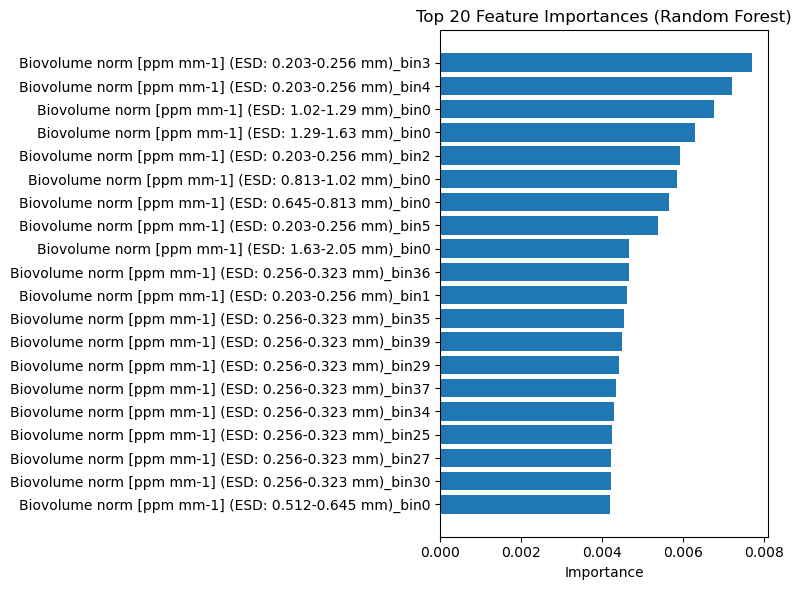

X_test_sample shape: (300, 680)
shap_values shape: (300, 680, 10)

=== SHAP Summary Plot for Class 0 ===


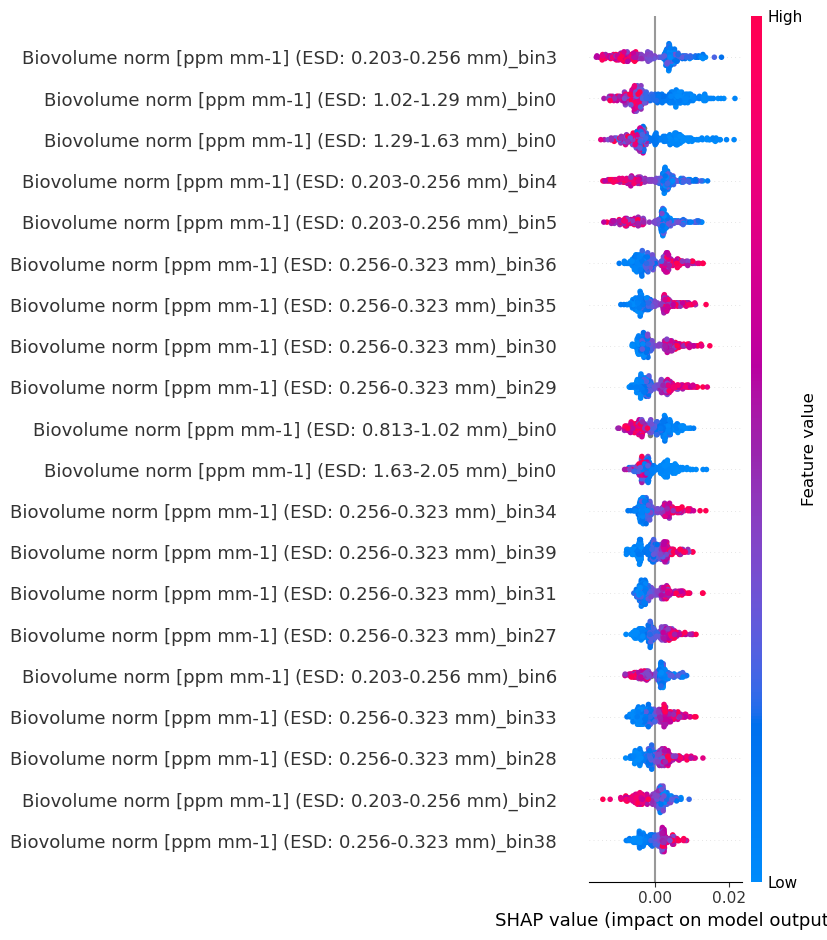


=== SHAP Summary Plot for Class 1 ===


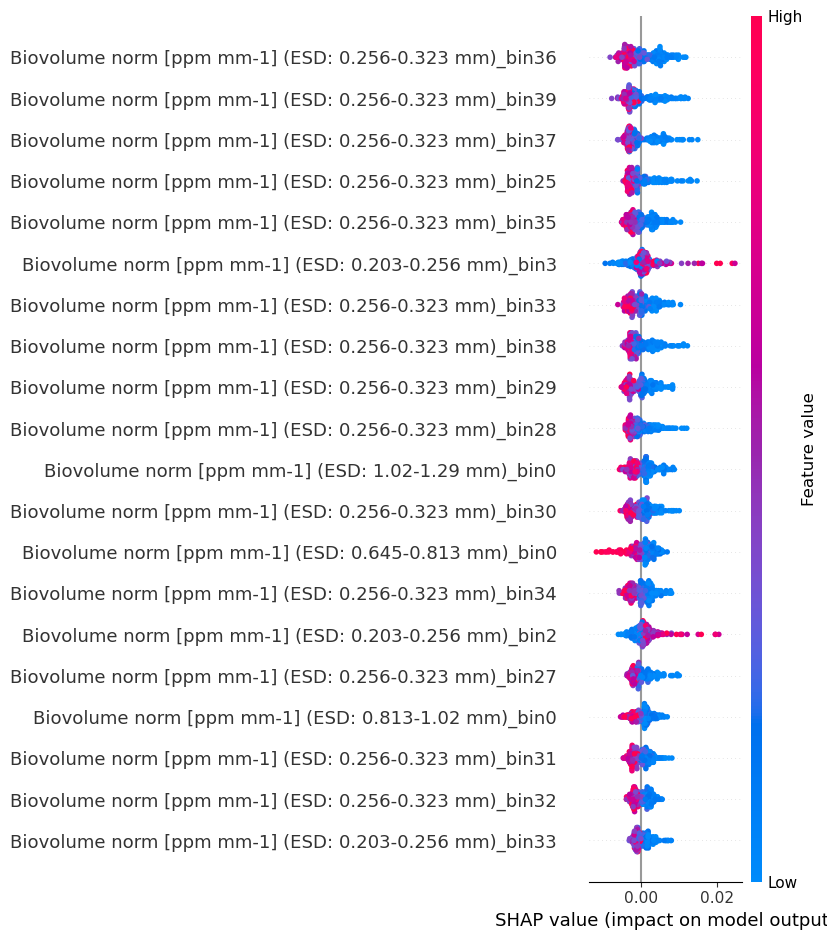


=== SHAP Summary Plot for Class 2 ===


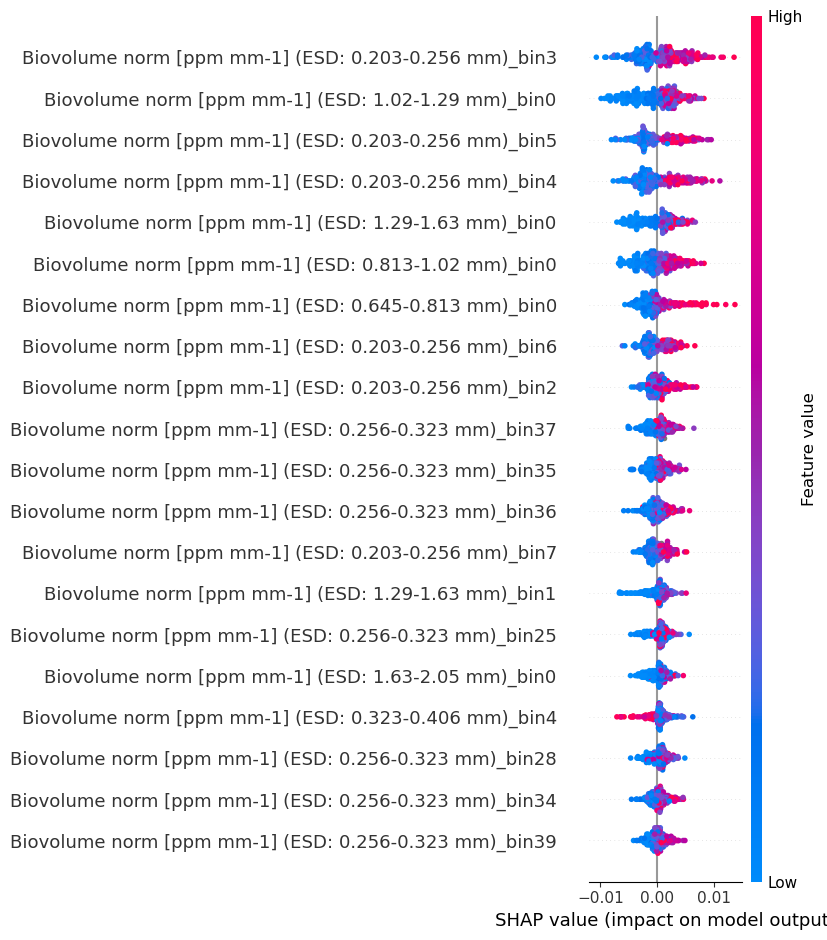


=== SHAP Summary Plot for Class 3 ===


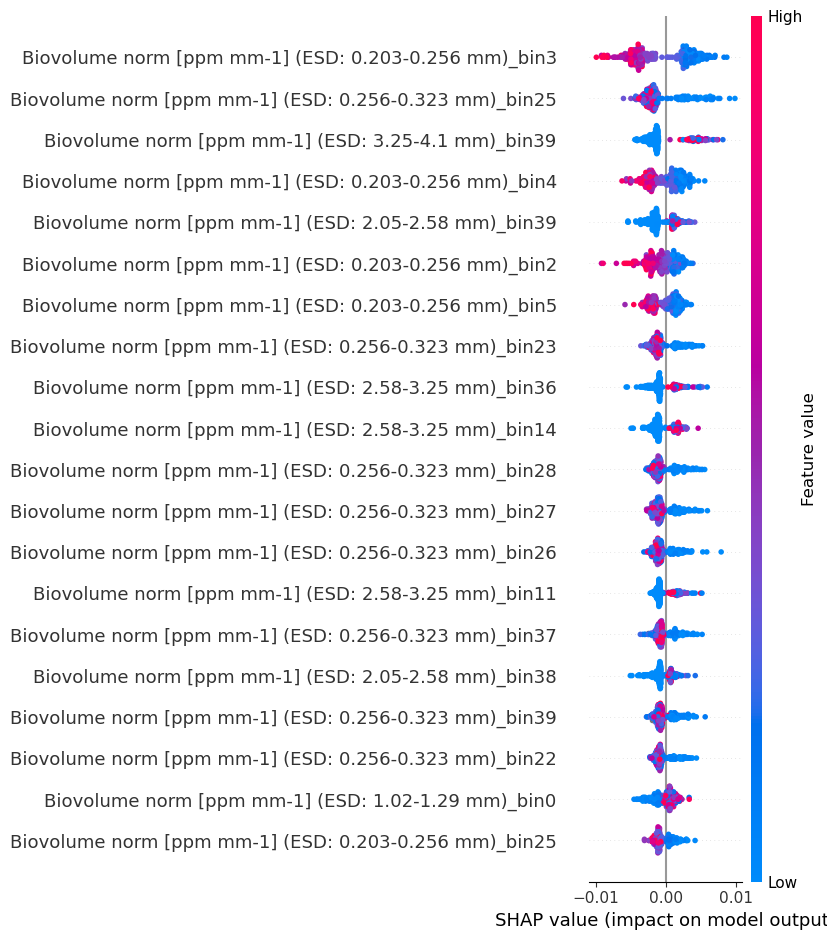


=== SHAP Summary Plot for Class 4 ===


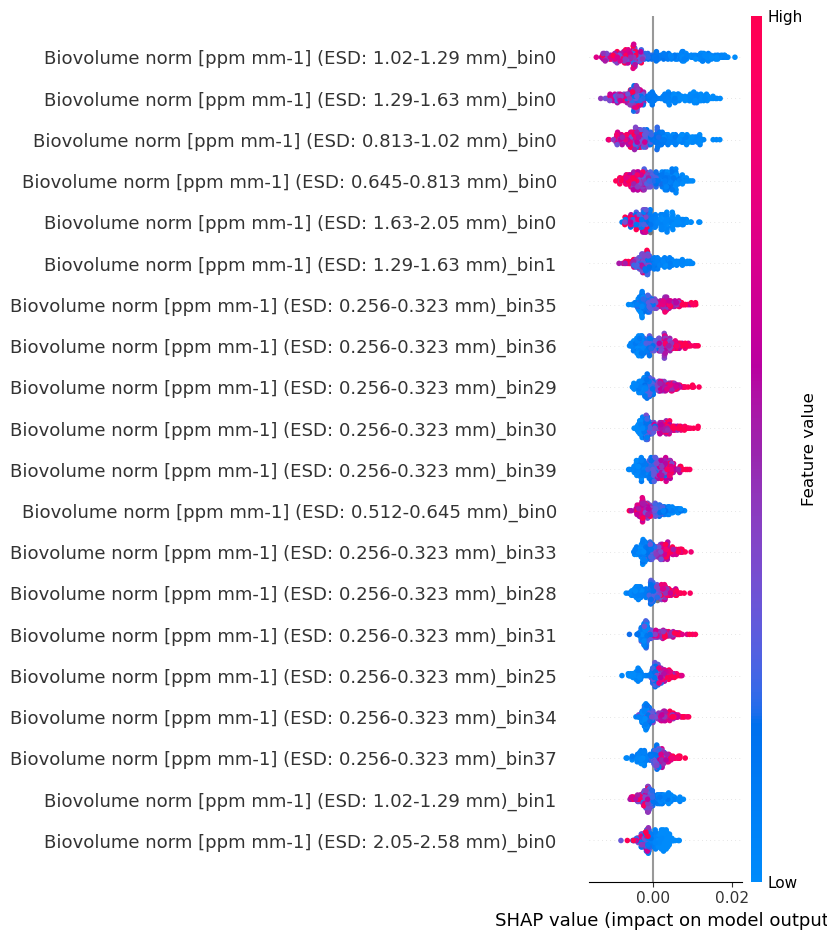


=== SHAP Summary Plot for Class 5 ===


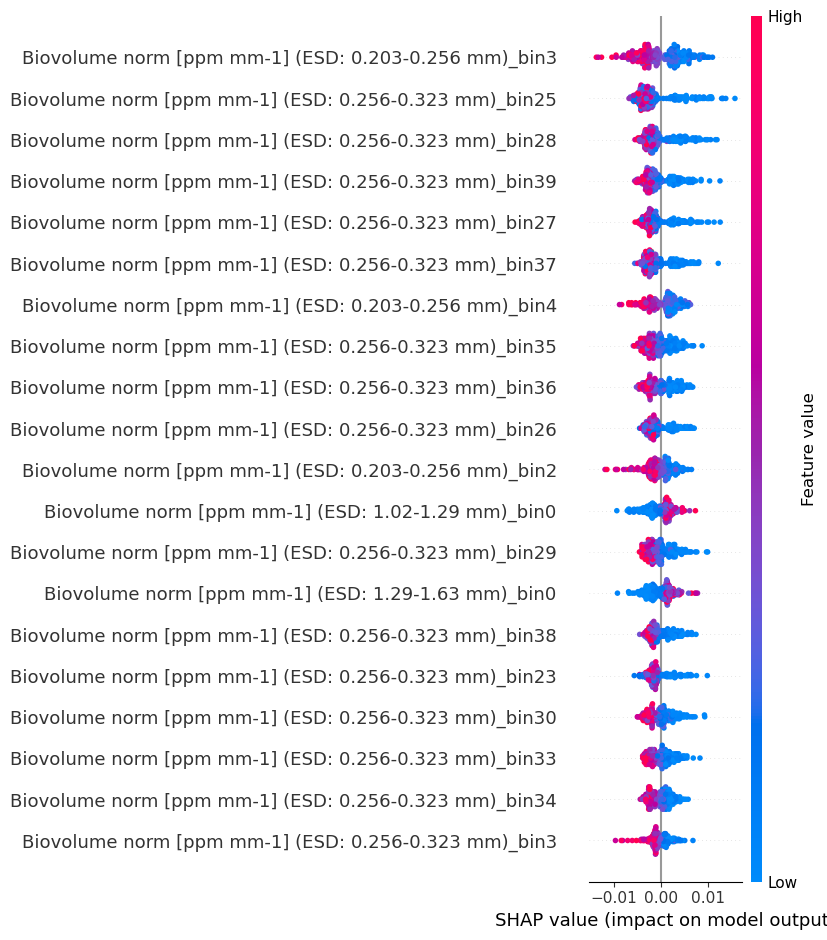


=== SHAP Summary Plot for Class 6 ===


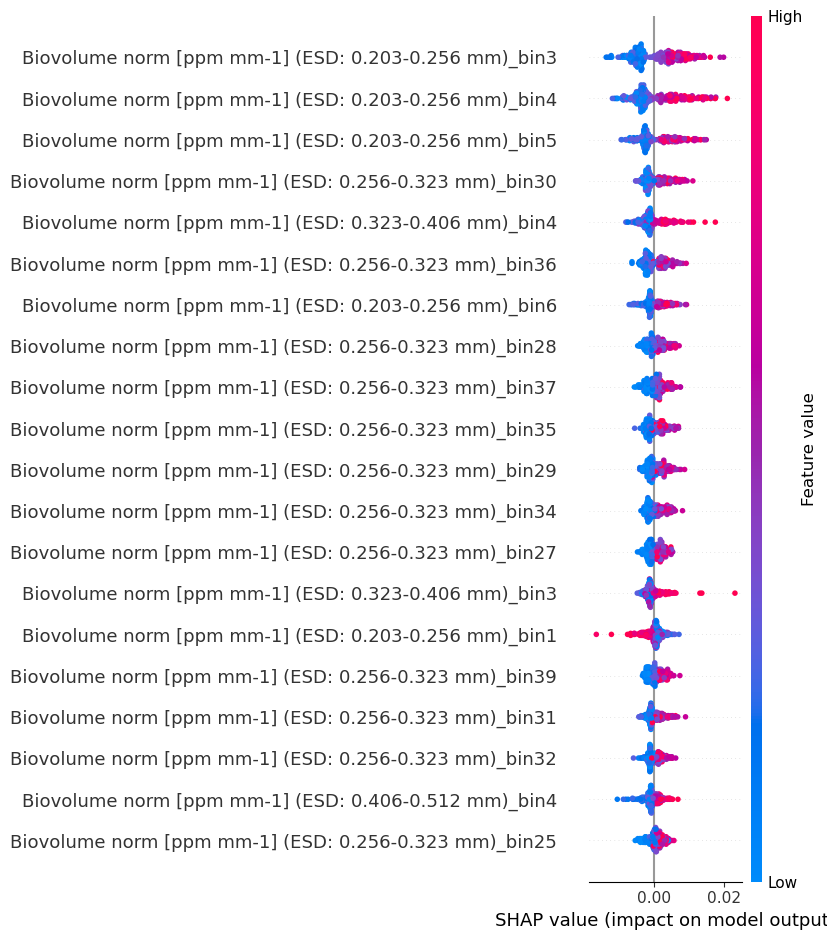


=== SHAP Summary Plot for Class 7 ===


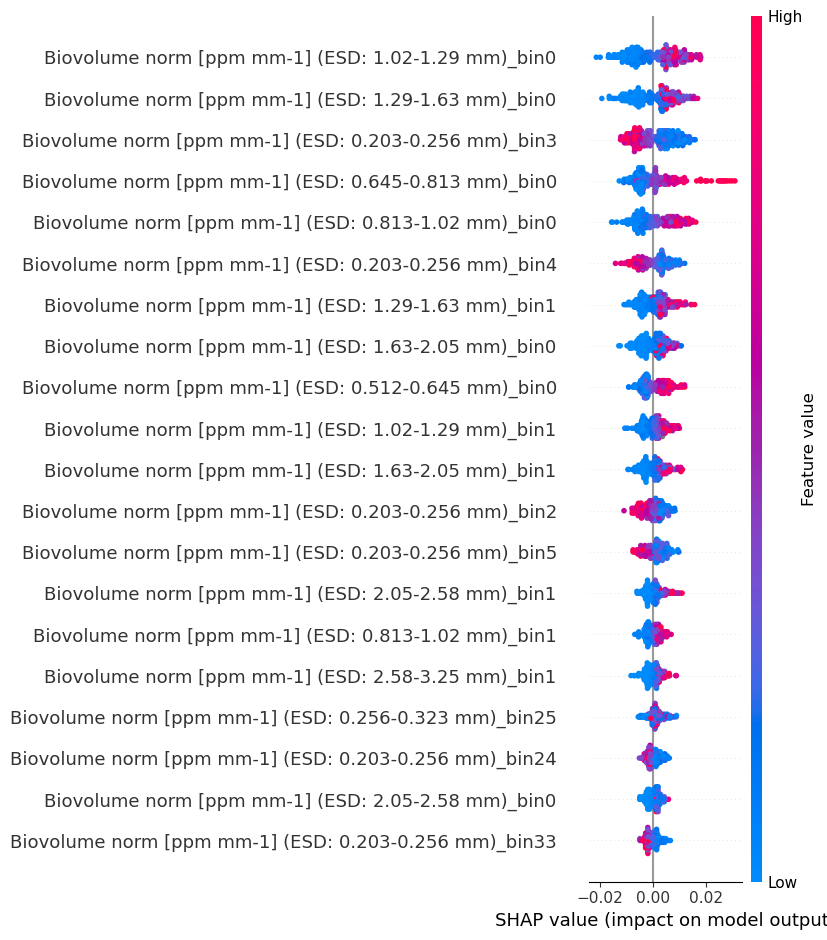


=== SHAP Summary Plot for Class 8 ===


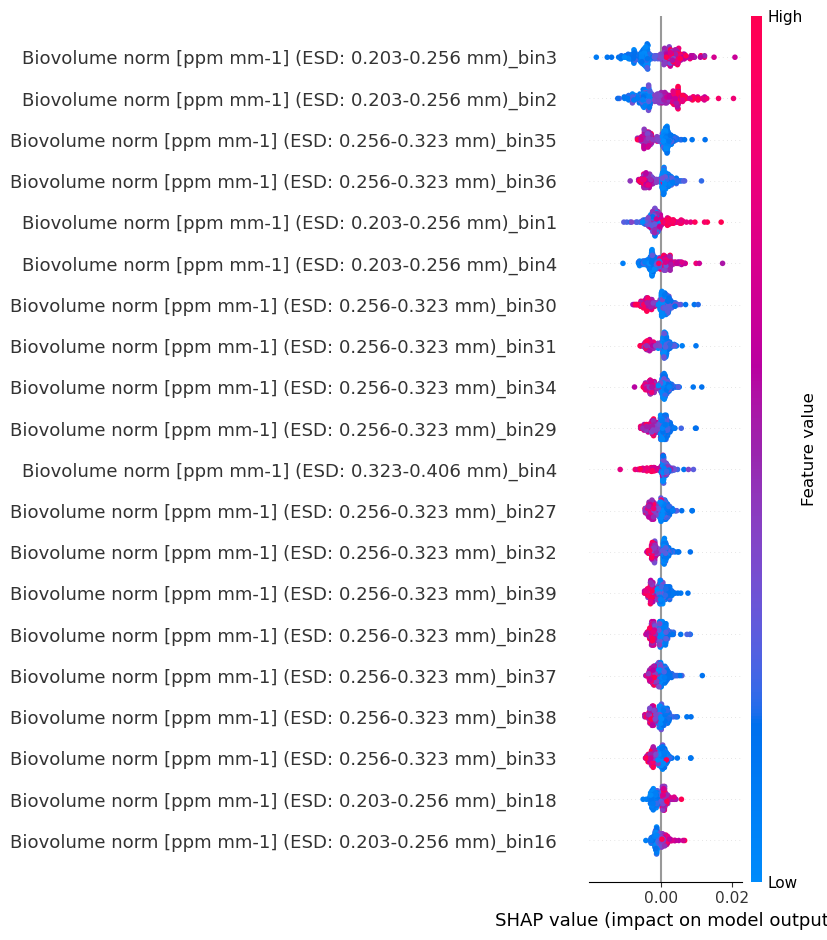


=== SHAP Summary Plot for Class 9 ===


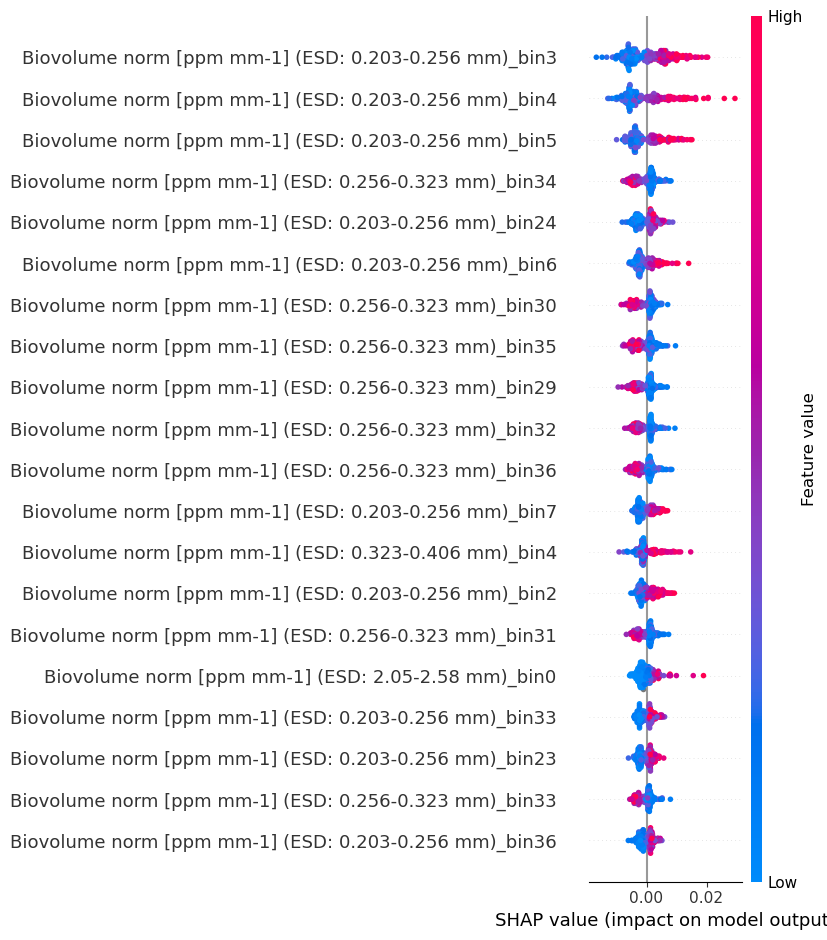


=== Top 20 Global SHAP Feature Importances ===
                                              Feature  MeanAbsSHAP
 Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin3     0.004400
 Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin4     0.003418
   Biovolume norm [ppm mm-1] (ESD: 1.02-1.29 mm)_bin0     0.003394
   Biovolume norm [ppm mm-1] (ESD: 1.29-1.63 mm)_bin0     0.002871
 Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin5     0.002503
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin36     0.002360
  Biovolume norm [ppm mm-1] (ESD: 0.813-1.02 mm)_bin0     0.002337
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin35     0.002204
 Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)_bin2     0.002190
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin25     0.002142
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin30     0.002124
 Biovolume norm [ppm mm-1] (ESD: 0.645-0.813 mm)_bin0     0.002124
Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)_bin39     0.002074
Biovolume norm

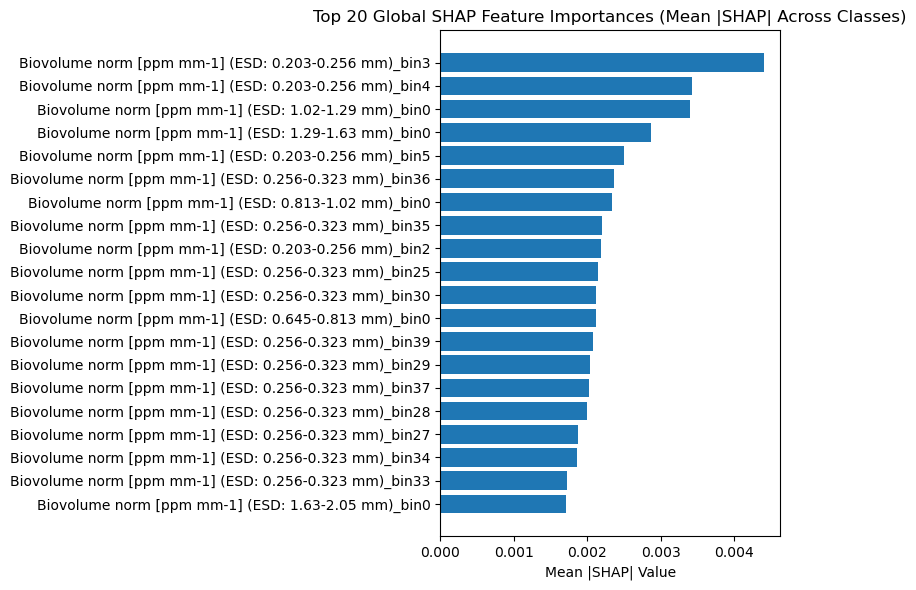

In [13]:
# -------------------------------
# Predictions on train and test data
# -------------------------------
y_pred_train = rf.predict(X_train_balanced)
y_pred_test  = rf.predict(X_test)

# -------------------------------
# Helper function to print metrics
# -------------------------------
def print_metrics(name, y_true, y_pred):
    print(f"\n=== {name} Metrics ===")
    print("Accuracy:          ", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy: ", balanced_accuracy_score(y_true, y_pred))
    print("Macro F1:          ", f1_score(y_true, y_pred, average='macro'))

# -------------------------------
# Train–test comparison
# -------------------------------
print_metrics("Train", y_train_balanced, y_pred_train)
print_metrics("Test",  y_test,          y_pred_test)

# -------------------------------
# Detailed evaluation (Test set only)
# -------------------------------
print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_pred_test, zero_division=0))

print("\n=== Confusion Matrix (Test) ===")
print(confusion_matrix(y_test, y_pred_test))

# -------------------------------
# Feature importance extraction
# -------------------------------
importances = rf.feature_importances_
feature_names = X_train_balanced.columns

feat_imp = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
      .sort_values(by="Importance", ascending=False)
      .reset_index(drop=True)
)

print("\n=== Top 20 Most Important Features ===")
print(feat_imp.head(20).to_string(index=False))

# Optional: bar plot of top 20 feature importances
top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(feat_imp["Feature"].head(top_n)[::-1],
         feat_imp["Importance"].head(top_n)[::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# =====================================================
# SHAP analysis (model explainability)
# =====================================================

#shap.initjs()

# Create explainer
explainer = shap.TreeExplainer(rf)

# Use a subset of the test data for speed
X_test_sample = X_test.sample(n=min(300, len(X_test)), random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)
shap_values = np.array(shap_values)   # expected shape: (n_samples, n_features, n_classes)

print("X_test_sample shape:", X_test_sample.shape)
print("shap_values shape:", shap_values.shape)

n_samples, n_features = X_test_sample.shape
_, sv_features, n_classes = shap_values.shape

assert sv_features == n_features, "Mismatch between SHAP feature dimension and X_test_sample"

# ---------------------------------------
# A: SHAP summary plot per class
# ---------------------------------------
for class_idx in range(n_classes):
    print(f"\n=== SHAP Summary Plot for Class {class_idx} ===")
    # shap_values for this class: (n_samples, n_features)
    sv_class = shap_values[:, :, class_idx]
    shap.summary_plot(sv_class, X_test_sample)

# ---------------------------------------
# B: Global SHAP importance across all classes
# ---------------------------------------
# Mean absolute SHAP over samples and classes -> (n_features,)
mean_abs_shap_per_feature = np.abs(shap_values).mean(axis=(0, 2))

shap_importance_df = (
    pd.DataFrame({
        "Feature": X_test_sample.columns,
        "MeanAbsSHAP": mean_abs_shap_per_feature
    })
    .sort_values("MeanAbsSHAP", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Top 20 Global SHAP Feature Importances ===")
print(shap_importance_df.head(20).to_string(index=False))

# Optional bar plot of global SHAP importances
top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(shap_importance_df["Feature"].head(top_n)[::-1],
         shap_importance_df["MeanAbsSHAP"].head(top_n)[::-1])
plt.title("Top 20 Global SHAP Feature Importances (Mean |SHAP| Across Classes)")
plt.xlabel("Mean |SHAP| Value")
plt.tight_layout()
plt.show()
    
